 TLS Traffic Analysis System with Autoencoders
--------------------------------------------
This module implements a system for analyzing TLS traffic patterns using autoencoders
to detect anomalies. It processes TLS records from JSON files, extracts relevant features,
and uses an autoencoder neural network to learn normal patterns.

The system can then evaluate new datasets against the learned patterns to identify
potential anomalies based on reconstruction error.

> This notebook involves processing the `tls.ccs` (Cipher Suite) field. 
> Extract the top N most frequent cipher suite values and create binary features to indicate their presence in each record.

## Install Python libraries

Install the following Python libraries if not already available in the current kernel.

In [2]:
!pip install matplotlib
!pip install tensorflow
!pip install scikit-learn

## Import Required Libraries

In [3]:
import math
import json
import glob
import os
import time
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, RepeatVector, TimeDistributed, Masking, Dropout

## Utility Functions for Composites and Divisors

In [4]:
def is_composite(x):
    """Return True if x is composite (not prime) and x >= 4; otherwise False."""
    if x < 4:
        return False  # 2 and 3 are prime; 1 is neither prime nor composite
    for i in range(2, int(math.sqrt(x)) + 1):
        if x % i == 0:
            return True
    return False


def find_nearest_composites(n):
    """Return the composite numbers greater than n."""
    candidates = []
    for i in range(n, int(n * 3 / 2)):
        if is_composite(i):
            candidates.append(i)
    return candidates


def greatest_divisor_pair(x):
    """
    Return the pair of divisors (d, x//d) for composite x such that
    d is the greatest divisor not exceeding sqrt(x). This pair is closest to each other.
    """
    d = int(math.sqrt(x))
    while d > 1:
        if x % d == 0:
            return (d, x // d)
        d -= 1
    return (1, x)


def get_padding_and_dim(x):
    """
    Find optimal dimensions for visualization by finding the nearest composite number
    that can be factored into dimensions with minimal difference.
    """
    dif = x
    val_x = x
    val_d1 = 0
    val_d2 = 0
    for nearest in find_nearest_composites(x):
        d1, d2 = greatest_divisor_pair(nearest)  
        if (math.fabs(d1-d2) > dif):
            return (val_x, val_d1, val_d2)
        else:
            val_x = nearest
            val_d1 = d1
            val_d2 = d2
            dif = math.fabs(d1-d2) 
    return (val_x, val_d1, val_d2)

# Data Processing Functions
def resize_row(row, maxlen, pad_value=0):
    """Resize a row in the array to the specified length."""
    current_length = len(row)
    if current_length < maxlen:
        # Calculate the amount of padding needed
        pad_width = maxlen - current_length
        # Pad at the end
        row = np.pad(row, pad_width=(0, pad_width), mode='constant', constant_values=pad_value)
    else:
        # If the row is longer than the target length, slice it
        row = row[:maxlen]
    return row

# Function to create a 2D image from a sample
def make_image_from_sample(sample, image_pad, image_dim_x, image_dim_y):
    return np.pad(sample, pad_width=(0, image_pad), mode='constant', constant_values=0).reshape(image_dim_x, image_dim_y)


# Function to pad sequences to a uniform length
def pad_sequences(sequences, maxlen, padding='post', truncating='post', pad_value=0):
    num_samples = len(sequences)
    padded_sequences = np.full((num_samples, maxlen), pad_value, dtype=float)
    
    for i, seq in enumerate(sequences):
        if not isinstance(seq, (list, np.ndarray)):
            continue
            
        seq = np.asarray(seq)
        if len(seq) == 0:
            continue
            
        if len(seq) >= maxlen:
            if truncating == 'pre':
                padded_sequences[i] = seq[-maxlen:]
            else:
                padded_sequences[i] = seq[:maxlen]
        else:
            if padding == 'pre':
                padded_sequences[i, -len(seq):] = seq
            else:
                padded_sequences[i, :len(seq)] = seq
                
    return padded_sequences


## Data Loading and Feature Extraction

In [5]:
# tls.CCS processing functions
def find_top_ccs_values(df, top_n):
    """
    Find the most common cipher suite values in the dataset.
    Returns a list of the top N most common values.
    """
    all_ccs = []
    for ccs_list in df['tls.ccs'].dropna():
        if isinstance(ccs_list, list):
            all_ccs.extend(ccs_list)
    
    # Calculate the frequency of each CCS value
    ccs_counter = Counter(all_ccs)
    
    # Get the most common CCS values
    top_ccs = [ccs for ccs, _ in ccs_counter.most_common(top_n)]
    
    print(f"Top {top_n} cipher suites: {top_ccs}")
    return top_ccs

def create_ccs_features(row, top_ccs):
    """
    Create binary features for each cipher suite in the top_ccs list.
    Returns a list of 0s and 1s indicating presence/absence of each cipher suite.
    """
    if not isinstance(row, list):
        return [0] * len(top_ccs)
    
    # Create a binary feature for each cipher suite
    return [1 if ccs in row else 0 for ccs in top_ccs]

def initialize_global_top_ccs(top_ccs):
    """Initialize the global top CCS list for consistent feature extraction."""
    global global_top_ccs
    global_top_ccs = top_ccs
    print(f"Initialized global top CCS list with {len(global_top_ccs)} values")

In [6]:
# Constants
RECORD_SEQUENCE_SIZE = 20
TOP_N_CCS = 30
TLS_COLUMNS_NAMES = np.array([f"tls.rec.{i}" for i in range(RECORD_SEQUENCE_SIZE)])

# Global variable to store top CCS values
global_top_ccs = None

def load_json_files(json_files):
    """
    Load data from the specified collection of JSON files.
    Returns raw data as a DataFrame.
    """
    all_data = []
    # Open each file and read each line
    for filename in json_files:
        with open(filename, "r") as file:
            # Load each line as a JSON object
            data = [json.loads(line.strip()) for line in file]
            all_data.extend(data)
    
    # Convert the list of dictionaries into a DataFrame
    df = pd.DataFrame(all_data)
    return df

def extract_features(df, use_global_ccs=False):
    """
    Extract features from the raw dataset.
    
    This function processes:
    - Flow related columns: 'bs', 'ps', 'br', 'pr', 'td'
    - TLS handshake columns: 'tls.cver', 'tls.sver', 'tls.scs'
    - TLS record sizes: 'tls.rec'
    - CCS features: Binary indicators for the most common cipher suites
    
    Returns a DataFrame with the extracted features and the list of top CCS values used.
    """
    global global_top_ccs
    
    # Determine which top CCS values to use
    if use_global_ccs and global_top_ccs is not None:
        top_ccs = global_top_ccs
        print(f"Using global top CCS list with {len(top_ccs)} values")
    else:
        top_ccs = find_top_ccs_values(df, top_n=TOP_N_CCS)
        # If this is the first time extracting features, store the values globally
        if global_top_ccs is None:
            initialize_global_top_ccs(top_ccs)
    
    # Create binary features for cipher suites
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    ccs_features = df['tls.ccs'].apply(lambda x: create_ccs_features(x, top_ccs))
    ccs_df = pd.DataFrame(ccs_features.tolist(), columns=ccs_column_names)
    
    # Process flow data
    flow_data = df[['bs', 'ps', 'br', 'pr', 'td']].astype(float)
    
    # Process TLS handshake data
    tls_data = df[['tls.cver','tls.sver','tls.scs']].fillna(0).astype(str) 
    
    # Process TLS records 
    records_data = pd.DataFrame(
        pad_sequences(df['tls.rec'].values, maxlen=RECORD_SEQUENCE_SIZE), 
        columns=TLS_COLUMNS_NAMES
    )
    
    # Combine all features into a single dataset
    dataset = pd.concat([flow_data, tls_data, records_data, ccs_df], axis=1).fillna(0)
    return dataset, top_ccs

def fit_preprocessor(df, top_ccs):
    """
    Create and fit a preprocessing pipeline for the extracted features.
    
    This pipeline includes:
    - MinMaxScaler for numerical features
    - OneHotEncoder for categorical features
    
    Returns the fitted pipeline that can be used for transforming data.
    """
    # Define cipher suite columns
    ccs_column_names = [f'tls.ccs.{ccs}' for ccs in top_ccs]
    
    # Create the column transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num_flow', MinMaxScaler(), ['bs', 'ps', 'br', 'pr', 'td']),
            ('num_tls', MinMaxScaler(), TLS_COLUMNS_NAMES),
            ('num_ccs', MinMaxScaler(), ccs_column_names), 
            ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['tls.cver','tls.sver','tls.scs'])
        ])
    
    # Create the pipeline with the preprocessor
    pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
    
    # Fit the pipeline on the data
    pipeline.fit(df)
    return pipeline

# Load normal data (desktop application TLS traffic)
raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
print(f'Dataset shape={raw_df.shape}')

# Extract features from the raw data
input_df, top_ccs = extract_features(raw_df)

# Store top CCS values globally for consistent feature extraction
global_top_ccs = top_ccs

# Create and fit the preprocessing pipeline
pipeline = fit_preprocessor(input_df, top_ccs)

# Transform the data using the pipeline
normal_df = pipeline.transform(input_df)

print('Normalized row of data:')
print(normal_df[0])
print(f'Dataset shape={normal_df.shape}')

# Prepare for visualization
row_len = normal_df.shape[1]
(new_row_len, IMAGE_DIM_X, IMAGE_DIM_Y) = get_padding_and_dim(row_len)
IMAGE_PAD = new_row_len - row_len
print(f"Visualization adjustment: {row_len} -> {new_row_len} (+ {IMAGE_PAD}) [{IMAGE_DIM_X} x {IMAGE_DIM_Y}]")

# Split data into training and testing sets
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'Train dataset={x_train.shape}')
print(f'Test dataset(normal)={x_test.shape}')

def make_image_from_sample(sample):
    return np.pad(sample, pad_width=(0,IMAGE_PAD), mode='constant', constant_values=0).reshape(IMAGE_DIM_X, IMAGE_DIM_Y)


Dataset shape=(14962, 28)
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0039', '0067']
Initialized global top CCS list with 30 values
Normalized row of data:
[2.17753132e-03 2.21631206e-03 9.79934060e-05 8.92359175e-04
 6.24198375e-03 8.35066163e-01 9.25056978e-03 1.61063331e-02
 4.89771620e-01 9.18864858e-02 4.91283677e-02 1.96893508e-01
 5.67007398e-02 3.53978244e-01 2.29417032e-01 3.23067383e-01
 3.14913671e-01 2.98925203e-01 2.89292228e-01 5.08128222e-01
 5.07518224e-01 5.00594748e-01 4.98520755e-01 4.99557752e-01
 4.99557752e-01 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 1.00000000e+00 1.00000000e+00 1.00000000e+00 1.00000000e+00
 0.00000000e+00 0.00000000e+00

## Define Autoencoder Architecture

The autoencoder is trained on `normal_df`. The data are split into training (80%) and testing (20%) parts. The size of laten space is set to `LATENT_SPACE_SIZE`.

The results are visualzied for the 10 selected sample. 

Read more: https://www.tensorflow.org/tutorials/generative/autoencoder

train dataset=(11969, 65)
test dataset(normal)=(2993, 65)
Epoch 1/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 975us/step - loss: 0.4324 - val_loss: 0.2292
Epoch 2/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step - loss: 0.2251 - val_loss: 0.2149
Epoch 3/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step - loss: 0.2097 - val_loss: 0.1989
Epoch 4/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 656us/step - loss: 0.1958 - val_loss: 0.1893
Epoch 5/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 643us/step - loss: 0.1879 - val_loss: 0.1836
Epoch 6/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 647us/step - loss: 0.1821 - val_loss: 0.1800
Epoch 7/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 0.1788 - val_loss: 0.1775
Epoch 8/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 0.1763 - val_loss: 0.1754
Epoch 9/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 1s 650us/step - loss: 0.1747 - val_loss: 0.1738
Epoch 10/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step - loss: 0.1727 - val_loss: 0.1723
Epoch 11/50
749/749 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - loss

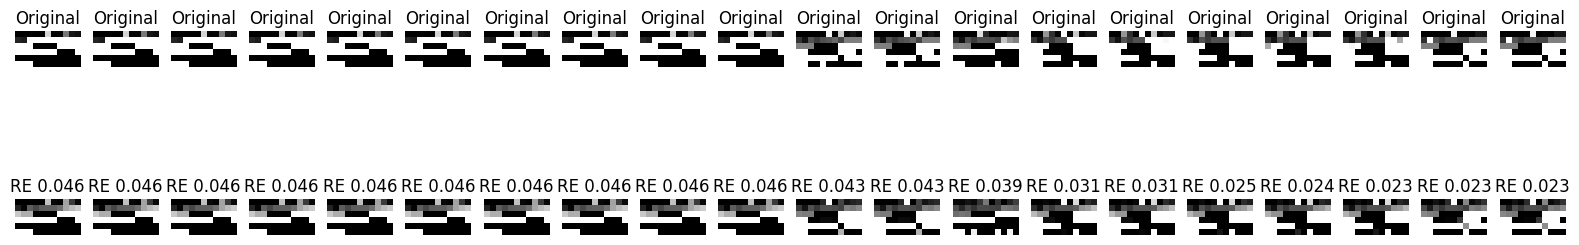

In [7]:
import os
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
LATENT_SPACE_SIZE=6

# Split data to traingin and testing
x_train, x_test = train_test_split(normal_df, test_size=0.2, random_state=42)
print(f'train dataset={x_train.shape}')
print(f'test dataset(normal)={x_test.shape}')

# Define dimensions and architecture
input_dim = x_train.shape[1]
encoding_dim = LATENT_SPACE_SIZE  # Size of the latent space

# Input placeholder
input_img = Input(shape=(input_dim,))

# Encoder layers
encoded = Dense(encoding_dim, activation='relu')(input_img)

# Decoder layers
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Autoencoder model
autoencoder = Model(input_img, decoded)

# Encoder model for later use
encoder = Model(input_img, encoded)

# Decoder model setup
encoded_input = Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = Model(encoded_input, decoder_layer(encoded_input))

# Compile and train the autoencoder
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.fit(x_train, x_train,
                epochs=50,                      # use some more reasonable number here (>50)
                batch_size=16,
                shuffle=True,
                validation_data=(x_test, x_test))

# Visualize the reconstructed images
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)

# Assuming x_test contains the original test data
# and decoded_imgs are the autoencoder's reconstructed outputs
reconstruction_errors = np.mean(np.square(x_test - decoded_imgs), axis=1)

# Average reconstruction error across all samples
avg_error = np.mean(reconstruction_errors)
max_error = np.max(reconstruction_errors)
min_error = np.min(reconstruction_errors)
print(f"Reconstruction error for each sample {reconstruction_errors}")
print(f"Average={avg_error}, Max={max_error}, Min={min_error} reconstruction errors.")

# Get indices that would sort the array in ascending order
worst20 = np.argsort(reconstruction_errors)[-20:][::-1]

n = 20  # Number of digits to display
i = 0

print("Worst reconstructed:")
plt.figure(figsize=(20, 4))
for j in worst20:
    reconstruction_error = reconstruction_errors[j]
    original = x_test[j]
    original = make_image_from_sample(original) 
    reconstructed = decoded_imgs[j]
    reconstructed = make_image_from_sample(reconstructed) 
    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')
    
    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(reconstructed, cmap='gray')
    plt.title(f"RE {reconstruction_error:.3f}")
    plt.axis('off')
    i+=1
plt.show()


## Test Dataset Function

Next, we load other dataset and use previously trained Autoencoder. The reconstruction error shuld be significantly higher.

In [8]:
def test_dataset(json_files, top_ccs, dataset_name="Unnamed Dataset", export_results=False, results_file="tls_test_results.xlsx"):
    """
    Test a TLS dataset and print detailed results in English.
    
    Parameters:
    -----------
    json_files : list or glob pattern
        The JSON files containing TLS records to test
    top_ccs : list
        List of top CCS values used during training
    dataset_name : str
        Name of the dataset being tested (for reporting)
    export_results : bool
        Whether to export results to Excel file
    results_file : str
        Path to Excel file for exporting results
    """
    # Start timing
    start_time = time.time()
    
    # Load and process data
    raw_test_df = load_json_files(json_files)
    
    # Find this dataset's own top CCS values (for analysis purposes)
    dataset_top_ccs = find_top_ccs_values(raw_test_df, top_n=TOP_N_CCS)
    print(f"Top 30 cipher suites in {dataset_name}: {dataset_top_ccs}")
    
    # Compare with training dataset's CCS values
    common_ccs = set(dataset_top_ccs) & set(top_ccs)
    unique_ccs = set(dataset_top_ccs) - set(top_ccs)
    print(f"CCS values in common with training data: {len(common_ccs)}")
    print(f"CCS values unique to this dataset: {len(unique_ccs)}")
    if unique_ccs:
        print(f"Unique CCS values: {', '.join(list(unique_ccs)[:10])}")
    
    # Use training top CCS for feature extraction to ensure model compatibility
    input_test_df, _ = extract_features(raw_test_df, use_global_ccs=True)
    
    # Transform data using the pipeline
    test_df = pipeline.transform(input_test_df)
    print(f"Processed dataset shape: {test_df.shape} ({test_df.shape[0]} samples with {test_df.shape[1]} features)")
    
    # Encode and decode using the autoencoder
    encoded_test = encoder.predict(test_df)
    decoded_test = decoder.predict(encoded_test)
        
    # Calculate reconstruction errors
    test_reconstruction_errors = np.mean(np.square(test_df - decoded_test), axis=1)
    
    # Calculate statistics
    test_avg_error = np.mean(test_reconstruction_errors)
    test_median_error = np.median(test_reconstruction_errors)
    test_std_error = np.std(test_reconstruction_errors)
    test_min_error = np.min(test_reconstruction_errors)
    test_max_error = np.max(test_reconstruction_errors)
    
    # Get percentiles for better distribution understanding
    percentiles = [25, 50, 75, 90, 95, 99]
    error_percentiles = np.percentile(test_reconstruction_errors, percentiles)
    
    # Get best and worst samples
    best10 = np.argsort(test_reconstruction_errors)[:10]
    worst10 = np.argsort(test_reconstruction_errors)[-10:][::-1]
    
    # Calculate elapsed time
    elapsed_time = time.time() - start_time
    
    # # Print comprehensive results
    # print("\nRECONSTRUCTION ERROR ANALYSIS:")
    # print(f"Average reconstruction error: {test_avg_error:.6f}")
    # print(f"Median reconstruction error:  {test_median_error:.6f}")
    # print(f"Std deviation of errors:      {test_std_error:.6f}")
    # print(f"Min reconstruction error:     {test_min_error:.6f}")
    # print(f"Max reconstruction error:     {test_max_error:.6f}")
    
    # print("\nERROR DISTRIBUTION (PERCENTILES):")
    # for p, val in zip(percentiles, error_percentiles):
    #     print(f"{p}th percentile: {val:.6f}")
    
    # # Print information about worst samples
    # print("\nWORST RECONSTRUCTED SAMPLES:")
    # for i, idx in enumerate(worst10):
    #     print(f"Sample {idx}: Reconstruction Error = {test_reconstruction_errors[idx]:.6f}")
    
    # # Print information about best samples
    # print("\nBEST RECONSTRUCTED SAMPLES:")
    # for i, idx in enumerate(best10):
    #     print(f"Sample {idx}: Reconstruction Error = {test_reconstruction_errors[idx]:.6f}")
    
    # Visualize results
    n = 10  # Number of samples to display
    plt.figure(figsize=(20, 4))
    for i, j in enumerate(worst10):
        rec_error = test_reconstruction_errors[j]
        original = test_df[j]
        original = make_image_from_sample(original)  
        reconstructed = decoded_test[j]
        reconstructed = make_image_from_sample(reconstructed)
        
        # Original images
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(original, cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed images
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed, cmap='gray')
        plt.title(f"RE {rec_error:.3f}")
        plt.axis('off')
    
    plt.suptitle(f"Worst Reconstructed Samples - {dataset_name}", fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()
    
    # Performance summary
    print("\nPERFORMANCE SUMMARY:")
    print(f"Dataset: {dataset_name}")
    print(f"Number of samples: {raw_test_df.shape[0]}")
    print(f"Number of features: {test_df.shape[1]}")
    print(f"Average reconstruction error: {test_avg_error:.6f}")
    print(f"Processing time: {elapsed_time:.2f} seconds")
    
    # Export results if requested
    if export_results:
        # Prepare results dictionary
        results_dict = {
            'Dataset Name': dataset_name,
            'Timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            'Number of Samples': raw_test_df.shape[0],
            'Number of Features': test_df.shape[1],
            'Average Error': test_avg_error,
            'Median Error': test_median_error,
            'Std Deviation': test_std_error,
            'Min Error': test_min_error,
            'Max Error': test_max_error,
            'Processing Time (s)': elapsed_time
        }
        
        # Add percentiles
        for p, val in zip(percentiles, error_percentiles):
            results_dict[f'Percentile {p}'] = val
        
        # Create DataFrame
        results_df = pd.DataFrame([results_dict])
        
        try:
            # Check if file exists
            if os.path.exists(results_file):
                existing_results = pd.read_excel(results_file)
                updated_results = pd.concat([existing_results, results_df], ignore_index=True)
            else:
                updated_results = results_df
                
            # Save to Excel
            updated_results.to_excel(results_file, index=False)
            print(f"\nResults successfully exported to {results_file}")
            
        except Exception as e:
            pass
    
    return {
        'dataset_name': dataset_name,
        'avg_error': test_avg_error,
        'median_error': test_median_error,
        'std_error': test_std_error,
        'min_error': test_min_error,
        'max_error': test_max_error,
        'raw_shape': raw_test_df.shape,
        'processed_shape': test_df.shape,
        'errors': test_reconstruction_errors,
        'top_ccs': dataset_top_ccs
    }


Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0039', '0067']
Top 30 cipher suites: ['002F', '0035', '000A', 'C00A', 'C009', 'C013', 'C014', 'C02B', '0005', '0004', '0033', '0039', '0032', 'C02F', 'C007', 'C011', '0038', '0045', '0088', '0016', '0041', '0084', 'C012', '009E', '009C', '003D', '003C', 'C023', 'C027', '0013']
Top 30 cipher suites in ISCX TLS Dataset: ['002F', '0035', '000A', 'C00A', 'C009', 'C013', 'C014', 'C02B', '0005', '0004', '0033', '0039', '0032', 'C02F', 'C007', 'C011', '0038', '0045', '0088', '0016', '0041', '0084', 'C012', '009E', '009C', '003D', '003C', 'C023', 'C027', '0013']
CCS values in common with training data: 16
CCS values unique to this dataset: 14
Unique CCS values: 0033, 0005, 0084, C011, 0016, 0004, 0013, 0045, 0032, C007
Using global top CCS list with 

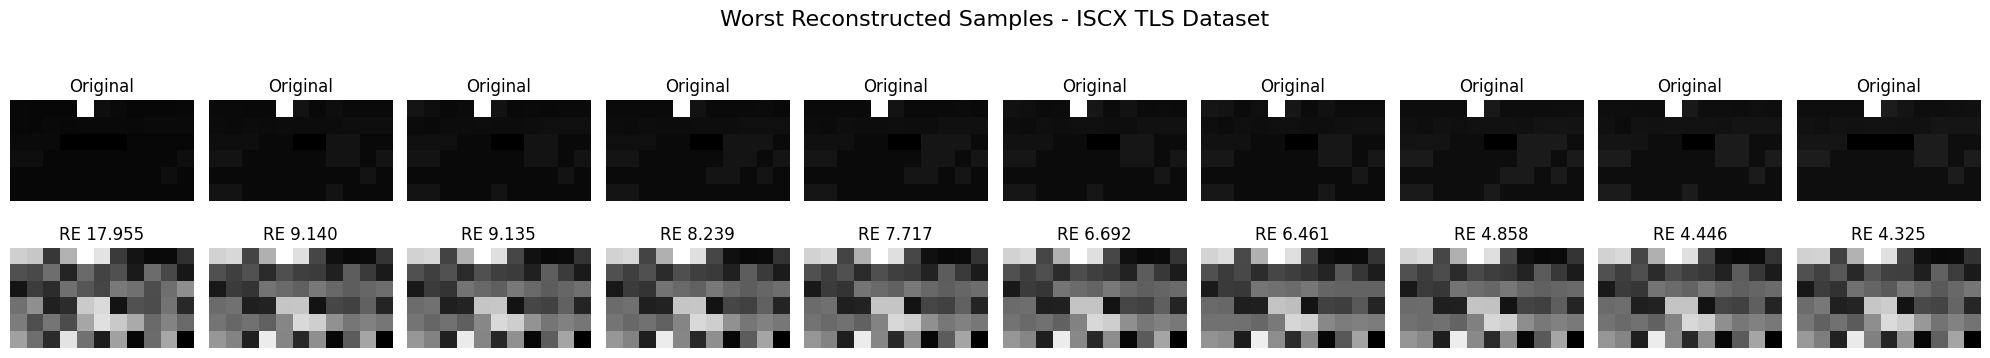


PERFORMANCE SUMMARY:
Dataset: ISCX TLS Dataset
Number of samples: 1112
Number of features: 65
Average reconstruction error: 0.319562
Processing time: 0.19 seconds
Top 30 cipher suites: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
Top 30 cipher suites in Mobile TLS Dataset: ['C02B', 'C02F', 'C02C', 'C030', 'CCA9', 'CCA8', '1301', '1302', '1303', 'C013', 'C014', '009C', '002F', '0035', '009D', 'C009', 'C00A', '000A', 'C008', 'C012', 'C024', 'C028', 'C023', 'C027', '003D', '003C', '00FF', '009F', 'CCAA', '009E']
CCS values in common with training data: 27
CCS values unique to this dataset: 3
Unique CCS values: CCAA, C012, C008
Using global top CCS list with 30 values
Processed dataset shape: (5616, 65) (5616 samples with 65 features)
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 338us/step
176/176 ━━━━━━━━━━━

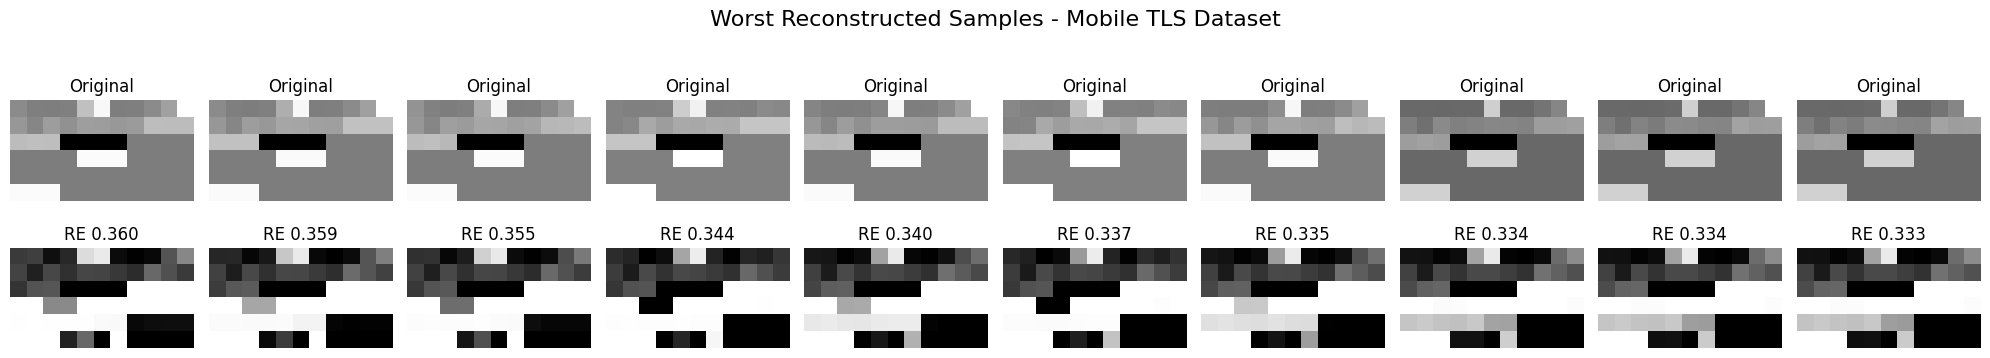


PERFORMANCE SUMMARY:
Dataset: Mobile TLS Dataset
Number of samples: 5616
Number of features: 65
Average reconstruction error: 0.017745
Processing time: 1.12 seconds
Top 30 cipher suites: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
Top 30 cipher suites in windows TLS Dataset: ['C02C', 'C02B', 'C030', 'C02F', 'C013', 'C014', '009C', '009D', '002F', '0035', 'CCA9', 'CCA8', '1302', '1301', '1303', 'C00A', 'C009', 'C027', '000A', 'C024', 'C023', 'C028', '003D', '003C', '009F', '009E', '00FF', '006B', '0067', '0039']
CCS values in common with training data: 30
CCS values unique to this dataset: 0
Using global top CCS list with 30 values
Processed dataset shape: (15047, 65) (15047 samples with 65 features)
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step
471/471 ━━━━━━━━━━━━━━━━━━━━ 0s 304us/step


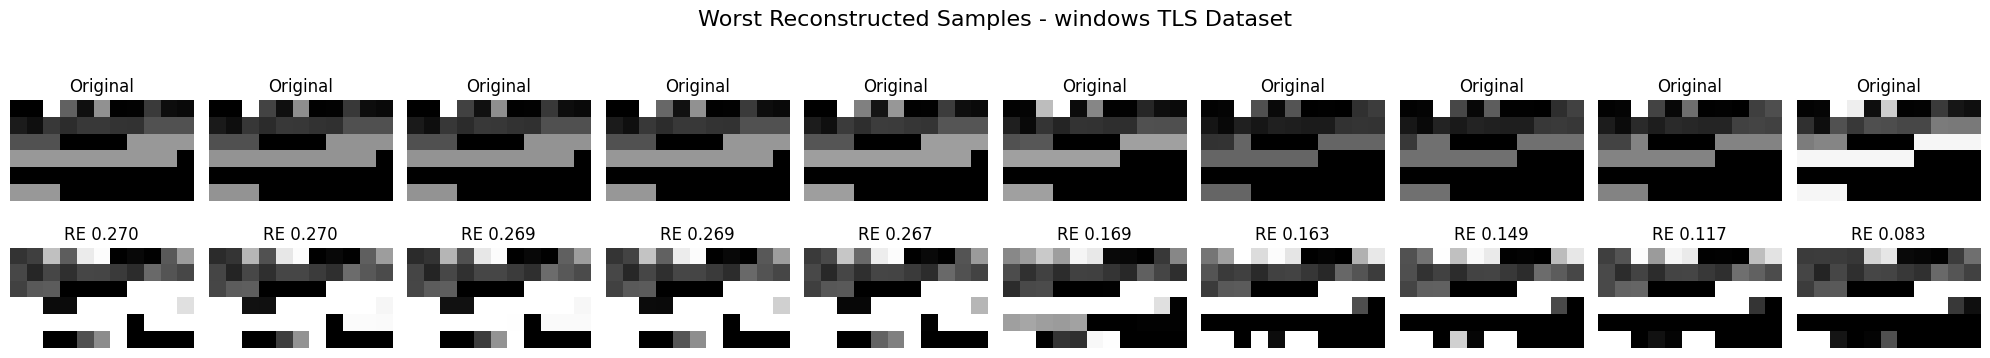


PERFORMANCE SUMMARY:
Dataset: windows TLS Dataset
Number of samples: 15047
Number of features: 65
Average reconstruction error: 0.002448
Processing time: 1.63 seconds
Top 30 cipher suites: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
Top 30 cipher suites in cic-aa.normal TLS Dataset: ['002F', '0035', 'C013', 'C014', 'C009', 'C00A', 'C02F', 'C02B', '009C', 'C030', 'C02C', '009D', '0033', '00FF', '0039', '009E', '0005', 'C011', 'C007', '009F', '000A', 'CC14', 'CC13', 'CCA9', 'CCA8', '0004', '0009', '0008', '0003', '0006']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0033, 0005, CC14, CC13, 0008, C011, 0006, 0009, 0003, 0004
Using global top CCS list with 30 values
Processed dataset shape: (31179, 65) (31179 samples with 65 features)
975/97

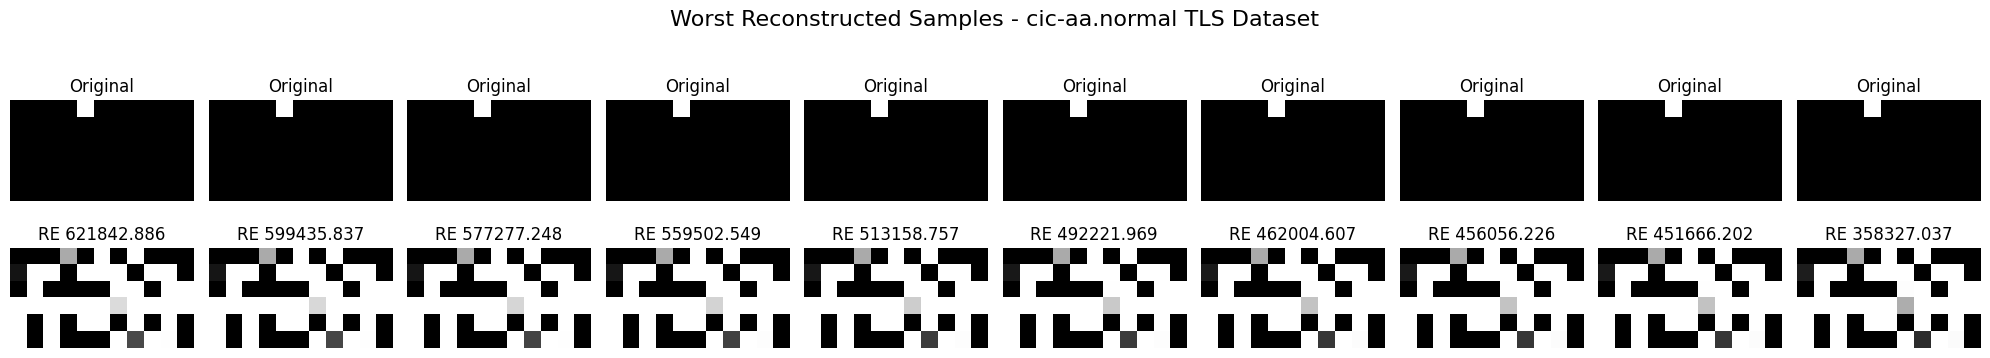


PERFORMANCE SUMMARY:
Dataset: cic-aa.normal TLS Dataset
Number of samples: 31179
Number of features: 65
Average reconstruction error: 379.243683
Processing time: 2.88 seconds
Top 30 cipher suites: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
Top 30 cipher suites in cic-aa.malware TLS Dataset: ['002F', '0035', 'C009', 'C00A', 'C013', 'C014', 'C02B', 'C02F', '009C', '0033', '0039', '009E', '00FF', '0005', 'C007', 'C011', 'C02C', 'C030', '009D', '009F', '000A', 'CCA9', 'CCA8', 'CC14', 'CC13', '0004', '0009', '0003', '0006', '0008']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0033, 0005, CC14, CC13, 0008, C011, 0006, 0009, 0003, 0004
Using global top CCS list with 30 values
Processed dataset shape: (462, 65) (462 samples with 65 features)
1

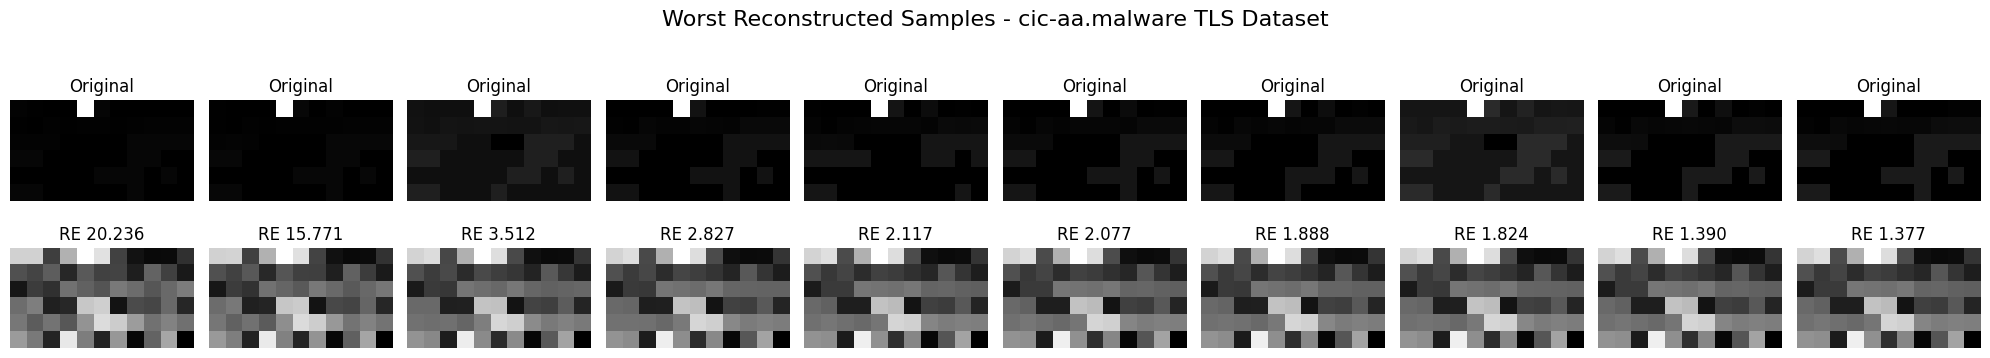


PERFORMANCE SUMMARY:
Dataset: cic-aa.malware TLS Dataset
Number of samples: 462
Number of features: 65
Average reconstruction error: 0.399875
Processing time: 0.15 seconds
Top 30 cipher suites: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
Top 30 cipher suites in cic-aa.adware TLS Dataset: ['C02B', 'C02F', '009E', 'C009', 'C00A', 'C013', 'C014', '0033', '0039', '009C', '002F', '0035', '00FF', 'C007', 'C011', '0005', 'C02C', 'C030', '009F', '009D', '000A', 'CC14', 'CC13', 'CC15', '0004', 'C028', 'C024', 'C022', 'C021', '00A3']
CCS values in common with training data: 19
CCS values unique to this dataset: 11
Unique CCS values: 0033, 0005, CC14, CC13, C011, CC15, 0004, 00A3, C007, C022
Using global top CCS list with 30 values
Processed dataset shape: (7122, 65) (7122 samples with 65 features)
223

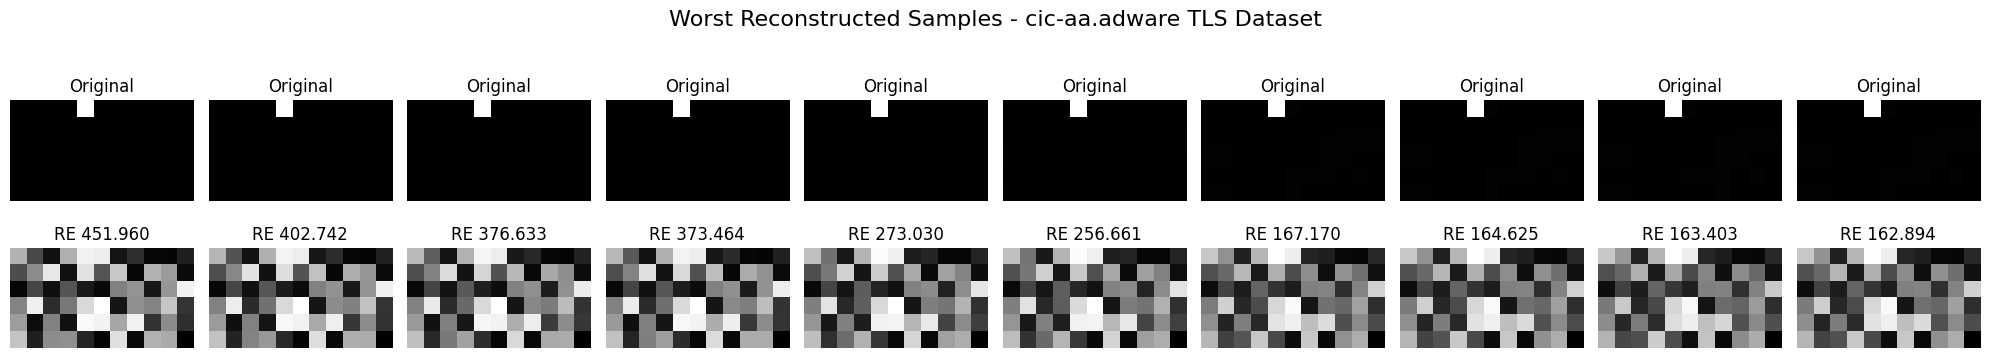


PERFORMANCE SUMMARY:
Dataset: cic-aa.adware TLS Dataset
Number of samples: 7122
Number of features: 65
Average reconstruction error: 0.899290
Processing time: 0.58 seconds

COMPARISON OF DATASETS
                   Dataset  Samples  Features  Avg Error     Max Error  Min Error
          ISCX TLS Dataset     1112        65   0.319562     17.954973   0.017574
        Mobile TLS Dataset     5616        65   0.017745      0.359911   0.000124
       windows TLS Dataset    15047        65   0.002448      0.270163   0.000095
 cic-aa.normal TLS Dataset    31179        65 379.243683 621842.885952   0.001166
cic-aa.malware TLS Dataset      462        65   0.399875     20.236371   0.014831
 cic-aa.adware TLS Dataset     7122        65   0.899290    451.960400   0.034955


In [9]:
results = {}

raw_df = load_json_files(glob.glob("../datasets/desktop.tls/*.json"))
input_df, top_ccs = extract_features(raw_df)

# Test ISCX dataset
results['iscx'] = test_dataset(
    json_files=glob.glob("../datasets/iscx.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="ISCX TLS Dataset",
    export_results=True
)

# Test Mobile dataset
results['mobile'] = test_dataset(
    glob.glob("../datasets/mobile.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="Mobile TLS Dataset",
    export_results=True
)

# Test Windows dataset
results['windows'] = test_dataset(
    glob.glob("../datasets/windows.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="windows TLS Dataset",
    export_results=True
)

# Test cic-aa.normal datasets
results['cic-aa.normal'] = test_dataset(
    glob.glob("../datasets/cic-aa.normal.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="cic-aa.normal TLS Dataset",
    export_results=True
)

# Test cic-aa.malware datasets
results['cic-aa.malware'] = test_dataset(
    glob.glob("../datasets/cic-aa.malware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="cic-aa.malware TLS Dataset",
    export_results=True
)

# Test cic-aa.adware datasets
results['cic-aa.adware'] = test_dataset(
    glob.glob("../datasets/cic-aa.adware.tls/*.json"),
    top_ccs=top_ccs,
    dataset_name="cic-aa.adware TLS Dataset",
    export_results=True
)


# Compare datasets
print("\n" + "="*80)
print("COMPARISON OF DATASETS")
print("="*80)

comparison_data = []
for name, result in results.items():
    comparison_data.append({
        'Dataset': result['dataset_name'],
        'Samples': result['raw_shape'][0],
        'Features': result['processed_shape'][1],
        'Avg Error': result['avg_error'],
        'Max Error': result['max_error'],
        'Min Error': result['min_error']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

## Reconstruction

In this section, threshold tuning was performed to optimize the anomaly detection process. Metrics such as recall, precision, and accuracy were observed across different threshold values to identify the optimal threshold for anomaly classification. The recall metric was particularly emphasized to ensure the detection of as many anomalies as possible.

For further details and reference, the implementation was inspired by the following repository:  
[Anomaly Detection with Autoencoders](https://github.com/AarnoStormborn/anomaly-detection-with-autoencoder/blob/main/anomaly-detection-with-autoencoders.ipynb)


In [10]:
# load the malicious dataset
abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.adware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/cic-aa.malware.tls/*.json"))
# abnormal_raw_df = load_json_files(glob.glob("../datasets/iscx.tls/*.json"))

input_abnormal_df, _ = extract_features(abnormal_raw_df, use_global_ccs=True)
    
abnormal_df = pipeline.transform(input_abnormal_df)

# calculate reconstruction errors for abnormal data
encoded_abnormal = encoder.predict(abnormal_df)
decoded_abnormal = decoder.predict(encoded_abnormal)
errors_abnormal = np.mean(np.square(abnormal_df - decoded_abnormal), axis=1)

# create a DataFrame for the reconstruction errors
recons_abnormal_df = pd.DataFrame({
    'error': errors_abnormal,
    'y_true': np.ones(len(errors_abnormal), dtype=int)
})

# let normal_df be the normal data
recons_normal_df = pd.DataFrame({
    'error': reconstruction_errors,
    'y_true': np.zeros(len(reconstruction_errors), dtype=int)  
})

recons_df = pd.concat([recons_normal_df, recons_abnormal_df], ignore_index=True)
recons_df.head()

Using global top CCS list with 30 values
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 332us/step


,error,y_true
0,0.000471,0
1,0.007567,0
2,0.000138,0
3,0.002511,0
4,0.003603,0


In [11]:
def thresholdTuning(df, iterations):
    
    thresh_df = {
        'threshold': [],
        'accuracy': [],
        'precision': [],
        'recall': []
    }
    
    for i in range(iterations):
        thresh_value = df['error'].quantile(i/iterations)
        preds = df['error'] > thresh_value
        cr = classification_report(df['y_true'], preds, output_dict=True)
        acc = cr['accuracy']
        prec = cr['macro avg']['precision']
        rc = cr['macro avg']['recall']
        
        thresh_df['threshold'].append(thresh_value)
        thresh_df['accuracy'].append(acc)
        thresh_df['precision'].append(prec)
        thresh_df['recall'].append(rc)
        
        print(f"Threshold: {thresh_value:.4f}\tAccuracy: {acc:.3f}\t\tPrecision: {prec:.3f}\tRecall Score: {rc:.3f}")
        
    return pd.DataFrame(thresh_df)
        
thresh_df = thresholdTuning(recons_df, 100)

Threshold: 0.0001	Accuracy: 0.704		Precision: 0.852	Recall Score: 0.500
Threshold: 0.0002	Accuracy: 0.714		Precision: 0.856	Recall Score: 0.517
Threshold: 0.0002	Accuracy: 0.724		Precision: 0.859	Recall Score: 0.534
Threshold: 0.0002	Accuracy: 0.734		Precision: 0.863	Recall Score: 0.551
Threshold: 0.0003	Accuracy: 0.744		Precision: 0.867	Recall Score: 0.568
Threshold: 0.0003	Accuracy: 0.754		Precision: 0.871	Recall Score: 0.585
Threshold: 0.0003	Accuracy: 0.764		Precision: 0.875	Recall Score: 0.601
Threshold: 0.0003	Accuracy: 0.774		Precision: 0.879	Recall Score: 0.618
Threshold: 0.0004	Accuracy: 0.784		Precision: 0.883	Recall Score: 0.635
Threshold: 0.0004	Accuracy: 0.794		Precision: 0.887	Recall Score: 0.652
Threshold: 0.0005	Accuracy: 0.804		Precision: 0.891	Recall Score: 0.669
Threshold: 0.0005	Accuracy: 0.814		Precision: 0.896	Recall Score: 0.686
Threshold: 0.0006	Accuracy: 0.824		Precision: 0.900	Recall Score: 0.703
Threshold: 0.0007	Accuracy: 0.834		Precision: 0.905	Recall Score

In [12]:
threshold = thresh_df[thresh_df['recall'] == thresh_df['recall'].max()]['threshold'].values[0]
print(f"Threshold with Maximum Recall: {threshold:.6f}")

Threshold with Maximum Recall: 0.117465


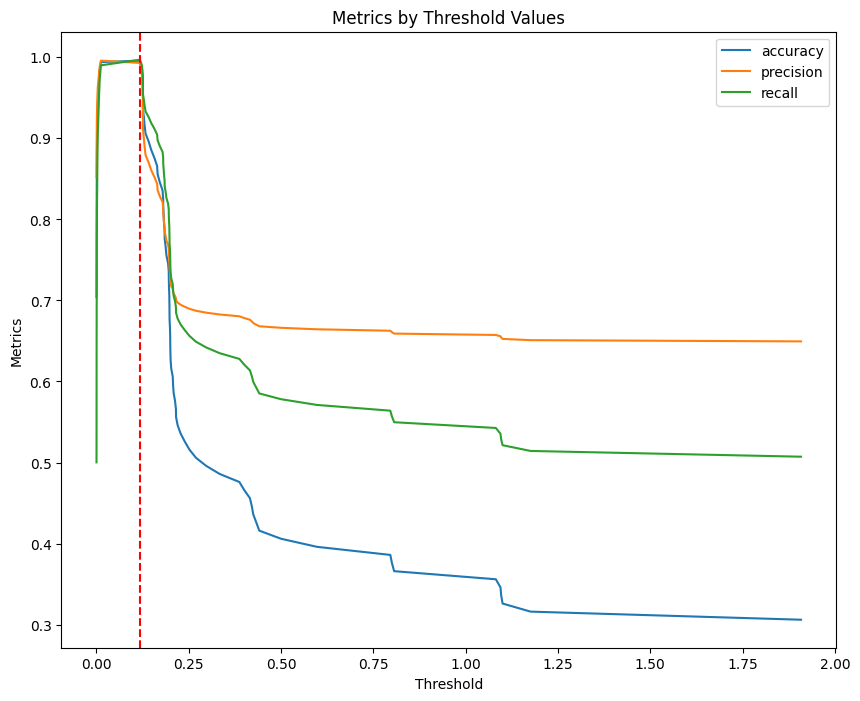

In [13]:
plt.figure(figsize=(10,8))
plt.plot(thresh_df['threshold'], thresh_df['accuracy'], label='accuracy')
plt.plot(thresh_df['threshold'], thresh_df['precision'], label='precision')
plt.plot(thresh_df['threshold'], thresh_df['recall'], label='recall')
plt.axvline(x=threshold, color='r', linestyle='dashed')
plt.xlabel('Threshold')
plt.ylabel('Metrics')
plt.title('Metrics by Threshold Values')
plt.legend()
plt.show()

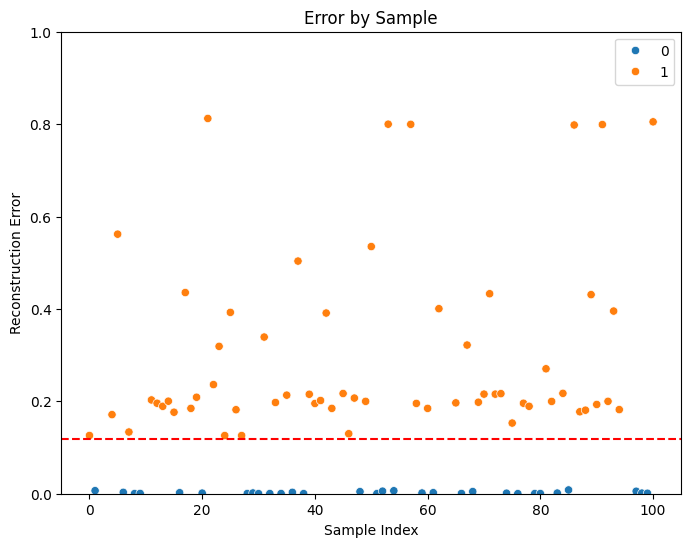

In [16]:
temp = recons_df.sample(frac=0.01, random_state=42).reset_index(drop=True)

plt.figure(figsize=(8,6))
sns.scatterplot(data=temp, x=temp.index, y='error', hue='y_true')
plt.axhline(y=threshold, color='r', linestyle='dashed')
plt.ylim(0, 1)  
plt.xlabel('Sample Index')
plt.ylabel('Reconstruction Error')
plt.title('Error by Sample')
plt.legend()
plt.show()
